# RFM Segmentation and Customer Profiling

In this task I built a complete customer-level RFM pipeline from raw transaction data and turns the scores into marketing-ready segments. The workflow follows the task requirements, but it also adds two practical safeguards: a tie-safe quantile scoring method and a segment-level revenue contribution view.

### What is included
- Data validation and date preparation
- Recency, Frequency and Monetary calculation
- 1–4 quantile scoring with `pd.qcut`
- Rule-based customer profiling with seven named segments
- Segment summary and marketing actions
- Required visualizations plus a 3D RFM plot and revenue-share chart
- CSV exports for downstream marketing use

In [1]:
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Keep tables readable inside the notebook.
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Loading the sales data

In [2]:
# Look for the dataset in the packaged data folder first.
candidates = [Path("data/sales_data_sample.csv"), Path("sales_data_sample.csv")]
data_path = next((path for path in candidates if path.exists()), None)

df = pd.read_csv(data_path, encoding="latin1")
print(f"Loaded: {data_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loaded: sales_data_sample.csv
Shape: 2,823 rows × 25 columns


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,"2,871.00",2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,"2,765.90",5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,"3,884.34",7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,"3,746.70",8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,"5,205.27",10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


## Quick quality check-up

RFM depends on four fields: customer name, order number, order date and sales. Before aggregation, it is worth confirming that these fields are complete and that duplicated rows are not silently inflating customer value.

In [3]:
# convert dates before checking the usable time window.
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"], errors="coerce")

critical_columns = ["CUSTOMERNAME", "ORDERNUMBER", "ORDERDATE", "SALES"]
quality_check = pd.DataFrame({
    "missing_values": df[critical_columns].isna().sum(),
    "missing_pct": df[critical_columns].isna().mean().mul(100).round(2)
})

print("Duplicate rows:", df.duplicated().sum())
print("Date range:", df["ORDERDATE"].min().date(), "to", df["ORDERDATE"].max().date())
display(quality_check)

# status is not filtered because the task asks for the complete sample-sales file.
display(df["STATUS"].value_counts().rename_axis("STATUS").to_frame("rows"))

Duplicate rows: 0
Date range: 2003-01-06 to 2005-05-31


,missing_values,missing_pct
CUSTOMERNAME,0,0.00
ORDERNUMBER,0,0.00
ORDERDATE,0,0.00
SALES,0,0.00


,rows
STATUS,
Shipped,2617
Cancelled,60
Resolved,47
On Hold,44
In Process,41
Disputed,14


## The customer-level RFM table

The reference date is defined as one day after the latest transaction, which prevents the most recent customers from receiving a Recency value of zero.

- **Recency:** days since the customer's latest order
- **Frequency:** number of unique `ORDERNUMBER` values
- **Monetary:** total `SALES` generated by the customer

Using unique order numbers is important here because each order can contain several product-line rows.

In [4]:
# this task explicitly requires max order date + 1 day.
reference_date = df["ORDERDATE"].max() + timedelta(days=1)
print("Reference date:", reference_date.date())

rfm = (
    df.groupby("CUSTOMERNAME")
      .agg(
          Recency=("ORDERDATE", lambda dates: (reference_date - dates.max()).days),
          Frequency=("ORDERNUMBER", "nunique"),
          Monetary=("SALES", "sum")
      )
      .reset_index()
)

print("Customers in RFM table:", rfm["CUSTOMERNAME"].nunique())
rfm.head()

Reference date: 2005-06-01
Customers in RFM table: 92


,CUSTOMERNAME,Recency,Frequency,Monetary
0,"AV Stores, Co.",196,3,"157,807.81"
1,Alpha Cognac,65,3,"70,488.44"
2,Amica Models & Co.,265,2,"94,117.26"
3,"Anna's Decorations, Ltd",84,4,"153,996.13"
4,Atelier graphique,188,3,"24,179.96"


In [5]:
# a compact statistical check to make unexpected aggregation errors visible early.
rfm_stats = rfm[["Recency", "Frequency", "Monetary"]].agg(["min", "max", "mean", "median"]).T
rfm_stats.columns = ["Min", "Max", "Mean", "Median"]
rfm_stats

,Min,Max,Mean,Median
Recency,1.00,509.00,182.83,186.00
Frequency,1.00,26.00,3.34,3.00
Monetary,"9,129.35","912,294.11","109,050.31","86,522.61"


### Dataset note

The supplied file contains **92 customers**, and the reference date resolves to **2005-06-01**, matching the task note. However, the exact RFM ranges in this file differ from some benchmark values shown in the assignment text. This notebook keeps the required definitions — especially *unique order count* for Frequency — and reports the values calculated from the uploaded dataset instead of forcing the data to match a preset result.

## Quantile scoring with tie handling

A direct `pd.qcut(rfm["Frequency"], 4)` fails because several customers share the same order counts and some quartile edges become identical. To preserve the required four scores, the metric is ranked first and `pd.qcut` is then applied to those ranks.

For **Frequency** and **Monetary**, a larger value receives a larger score. **Recency is inverted**: fewer days since the last purchase is better, so the lowest recency quartile receives score 4.

In [6]:
def quartile_score(series, labels):
    """Return four qcut-based scores while avoiding duplicate bin edges from ties."""
    ranked = series.rank(method="first")
    return pd.qcut(ranked, q=4, labels=labels).astype(int)

# lower recency is stronger, hence the reversed labels.
rfm["R_Score"] = quartile_score(rfm["Recency"], labels=[4, 3, 2, 1])
rfm["F_Score"] = quartile_score(rfm["Frequency"], labels=[1, 2, 3, 4])
rfm["M_Score"] = quartile_score(rfm["Monetary"], labels=[1, 2, 3, 4])

rfm["RFM_Segment"] = rfm[["R_Score", "F_Score", "M_Score"]].astype(str).agg("".join, axis=1)
rfm["RFM_Total"] = rfm[["R_Score", "F_Score", "M_Score"]].sum(axis=1)

# each metric should contain four equally sized score groups for 92 customers.
display(rfm[["R_Score", "F_Score", "M_Score"]].apply(pd.Series.value_counts).sort_index())
rfm.head()

,R_Score,F_Score,M_Score
1,23,23,23
2,23,23,23
3,23,23,23
4,23,23,23


,CUSTOMERNAME,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Total
0,"AV Stores, Co.",196,3,"157,807.81",2,2,4,224,8
1,Alpha Cognac,65,3,"70,488.44",4,2,2,422,8
2,Amica Models & Co.,265,2,"94,117.26",1,1,3,113,5
3,"Anna's Decorations, Ltd",84,4,"153,996.13",3,4,4,344,11
4,Atelier graphique,188,3,"24,179.96",2,2,1,221,5


## Converting RFM scores into business segments

Rather than using a generic score sum alone, the rules below retain the three-dimensional behavior of each customer. The ordering of the rules is intentional: high-priority groups such as Champions and At Risk are assigned before broader catch-all profiles.

| Segment | Rule | Business interpretation |
|---|---|---|
| Champions | `444` | Best on all three RFM dimensions |
| Loyal | `R≥3, F≥3, M≥3` | Active, repeat, high-value customers |
| At Risk | `R≤2, F≥3, M≥3` | Historically valuable but becoming inactive |
| Potential Loyalists | `R≥3, F≥2, M≥2` | Recent customers with room to deepen engagement |
| Needs Attention | `R in {2,3}` and `F≥2 or M≥2` | Mid-strength customers who may drift |
| Lost | `111` | Weak on recency, frequency and value |
| Low Engagement | remaining combinations | Customers without a strong behavioral pattern yet |

In [7]:
def assign_segment(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]

    # highest-value patterns first.
    if (r, f, m) == (4, 4, 4):
        return "Champions"
    if r >= 3 and f >= 3 and m >= 3:
        return "Loyal"
    if r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    if r >= 3 and f >= 2 and m >= 2:
        return "Potential Loyalists"
    if r in (2, 3) and (f >= 2 or m >= 2):
        return "Needs Attention"
    if (r, f, m) == (1, 1, 1):
        return "Lost"
    return "Low Engagement"

segment_order = [
    "Champions", "Loyal", "Potential Loyalists", "At Risk",
    "Needs Attention", "Lost", "Low Engagement"
]

rfm["Segment"] = rfm.apply(assign_segment, axis=1)
rfm["Segment"] = pd.Categorical(rfm["Segment"], categories=segment_order, ordered=True)

rfm[["CUSTOMERNAME", "Recency", "Frequency", "Monetary", "RFM_Segment", "Segment"]].head(10)

,CUSTOMERNAME,Recency,Frequency,Monetary,RFM_Segment,Segment
0,"AV Stores, Co.",196,3,"157,807.81",224,Needs Attention
1,Alpha Cognac,65,3,"70,488.44",422,Potential Loyalists
2,Amica Models & Co.,265,2,"94,117.26",113,Low Engagement
3,"Anna's Decorations, Ltd",84,4,"153,996.13",344,Loyal
4,Atelier graphique,188,3,"24,179.96",221,Needs Attention
5,"Australian Collectables, Ltd",23,3,"64,591.46",421,Low Engagement
6,"Australian Collectors, Co.",184,5,"200,995.41",344,Loyal
7,"Australian Gift Network, Co",119,3,"59,469.12",321,Needs Attention
8,Auto Assoc. & Cie.,233,2,"64,834.32",111,Lost
9,Auto Canal Petit,55,3,"93,170.66",423,Potential Loyalists


## Segment summary

The summary table goes beyond customer counts: revenue contribution is added so marketing teams can distinguish a large segment from a financially important one.

In [8]:
segment_summary = (
    rfm.groupby("Segment", observed=False)
       .agg(
           Customer_Count=("CUSTOMERNAME", "count"),
           Avg_Recency=("Recency", "mean"),
           Avg_Frequency=("Frequency", "mean"),
           Avg_Monetary=("Monetary", "mean"),
           Total_Revenue=("Monetary", "sum"),
           Avg_R_Score=("R_Score", "mean"),
           Avg_F_Score=("F_Score", "mean"),
           Avg_M_Score=("M_Score", "mean")
       )
       .reset_index()
)

segment_summary["Revenue_Share_Pct"] = (
    segment_summary["Total_Revenue"] / rfm["Monetary"].sum() * 100
)

segment_summary.round({
    "Avg_Recency": 1, "Avg_Frequency": 2, "Avg_Monetary": 2,
    "Total_Revenue": 2, "Revenue_Share_Pct": 2,
    "Avg_R_Score": 2, "Avg_F_Score": 2, "Avg_M_Score": 2
})

,Segment,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Avg_R_Score,Avg_F_Score,Avg_M_Score,Revenue_Share_Pct
0,Champions,9,19.40,8.11,"290,097.74","2,610,879.63",4.00,4.00,4.00,26.02
1,Loyal,17,110.30,3.59,"132,894.92","2,259,213.63",3.24,3.47,3.47,22.52
2,Potential Loyalists,13,72.40,3.00,"82,951.31","1,078,367.02",3.69,2.54,2.23,10.75
3,At Risk,7,239.00,3.29,"125,489.83","878,428.84",1.86,3.43,3.57,8.76
4,Needs Attention,20,189.20,2.90,"77,039.77","1,540,795.33",2.25,2.30,2.05,15.36
5,Lost,11,360.50,1.91,"52,366.99","576,036.90",1.00,1.00,1.00,5.74
6,Low Engagement,15,293.90,2.13,"72,593.83","1,088,907.50",1.47,1.40,1.93,10.85


## Marketing actions

Segmentation only becomes useful when it changes an action. These recommendations are deliberately different by customer state: high-value active customers are protected, drifting customers receive timely win-back treatment, and low-value inactive customers are handled with lower-cost outreach.

In [9]:
marketing_actions = pd.DataFrame([
    ["Champions", "Protect and amplify",
     "Offer VIP early access, premium bundles and referral rewards; avoid blanket discounts that erode margin."],
    ["Loyal", "Deepen the relationship",
     "Use loyalty milestones, personalized cross-sell recommendations and replenishment reminders to move strong repeat buyers upward."],
    ["Potential Loyalists", "Build the next habit",
     "Trigger a second/third-order incentive within 30–45 days and recommend products adjacent to the customer’s recent categories."],
    ["At Risk", "Win back before churn",
     "Launch a time-limited win-back campaign based on prior spend, surface previously purchased categories, and ask for a short reason-for-leaving signal."],
    ["Needs Attention", "Re-engage selectively",
     "Use product-interest reminders and moderate incentives; prioritize customers with above-median monetary value rather than mass messaging."],
    ["Lost", "Reactivate cheaply",
     "Test one low-cost reactivation touch. If there is no response, reduce contact frequency to avoid wasting campaign budget."],
    ["Low Engagement", "Nurture with low friction",
     "Use educational or discovery content, low-commitment offers and category recommendations to create another purchase occasion."]
], columns=["Segment", "Business_Goal", "Recommended_Action"])

marketing_actions

,Segment,Business_Goal,Recommended_Action
0,Champions,Protect and amplify,"Offer VIP early access, premium bundles and re..."
1,Loyal,Deepen the relationship,"Use loyalty milestones, personalized cross-sel..."
2,Potential Loyalists,Build the next habit,Trigger a second/third-order incentive within ...
3,At Risk,Win back before churn,Launch a time-limited win-back campaign based ...
4,Needs Attention,Re-engage selectively,Use product-interest reminders and moderate in...
5,Lost,Reactivate cheaply,Test one low-cost reactivation touch. If there...
6,Low Engagement,Nurture with low friction,"Use educational or discovery content, low-comm..."


## Visualizations

The first three charts satisfy the task specification. They answer three separate questions: **how large each segment is**, **where customer value sits relative to recency**, and **how the average R/F/M score profile differs across segments**.

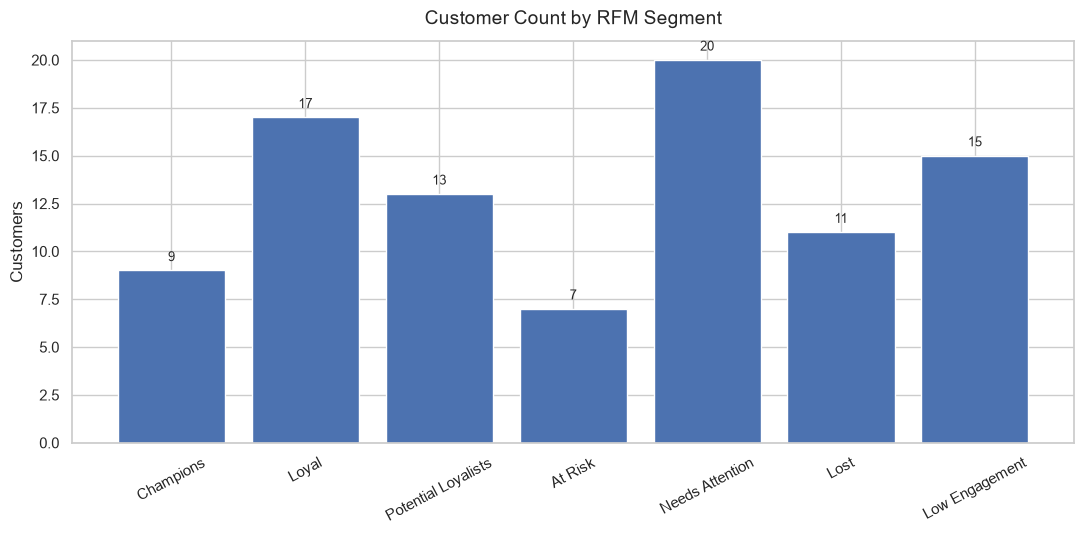

In [10]:
# 1) Segment sizes
plot_counts = (
    rfm["Segment"].value_counts(sort=False)
       .reindex(segment_order)
       .dropna()
)

plt.figure(figsize=(11, 5.5))
ax = plt.gca()
ax.bar([str(x) for x in plot_counts.index], plot_counts.values)
ax.set_title("Customer Count by RFM Segment", fontsize=14, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Customers")
ax.tick_params(axis="x", rotation=28)

for i, value in enumerate(plot_counts.values):
    ax.text(i, value + 0.35, str(int(value)), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_segment_sizes.png", dpi=180, bbox_inches="tight")
plt.show()

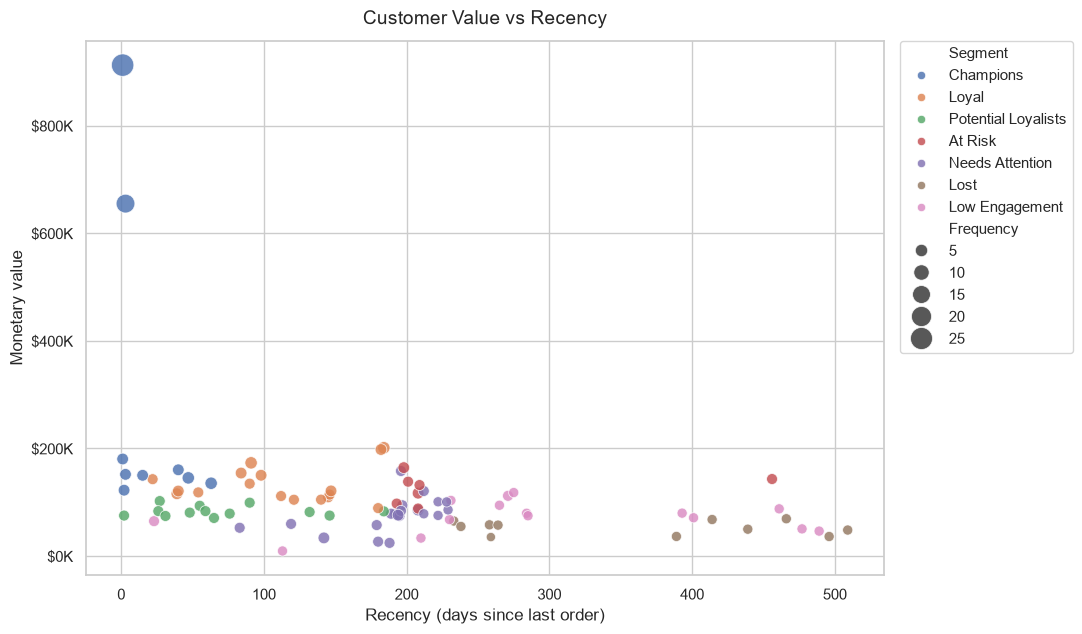

In [11]:
# 2) Recency vs Monetary, colored by segment
plt.figure(figsize=(11, 6.5))
ax = sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Segment",
    size="Frequency",
    sizes=(45, 260),
    alpha=0.82
)
ax.set_title("Customer Value vs Recency", fontsize=14, pad=12)
ax.set_xlabel("Recency (days since last order)")
ax.set_ylabel("Monetary value")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_recency_vs_monetary.png", dpi=180, bbox_inches="tight")
plt.show()

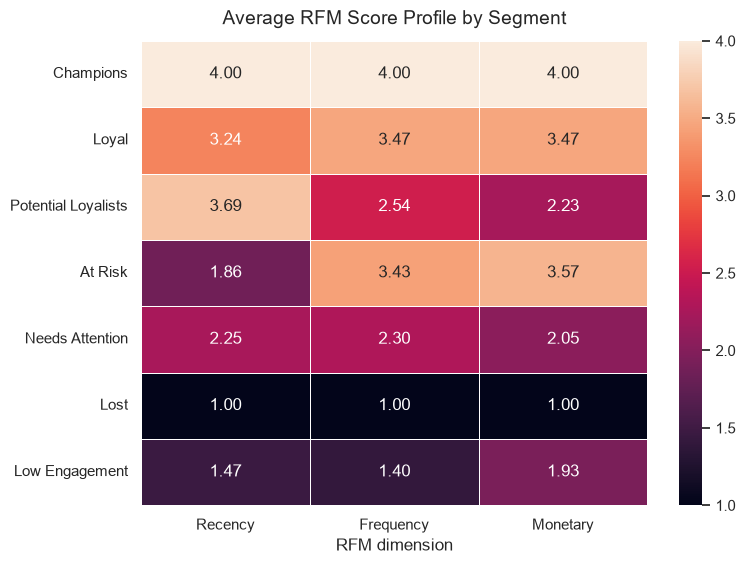

In [12]:
# 3) Heatmap of average RFM scores by segment
heatmap_data = (
    segment_summary.set_index("Segment")[["Avg_R_Score", "Avg_F_Score", "Avg_M_Score"]]
    .rename(columns={"Avg_R_Score": "Recency", "Avg_F_Score": "Frequency", "Avg_M_Score": "Monetary"})
)

plt.figure(figsize=(8, 5.8))
ax = sns.heatmap(heatmap_data, annot=True, fmt=".2f", linewidths=0.5, vmin=1, vmax=4)
ax.set_title("Average RFM Score Profile by Segment", fontsize=14, pad=12)
ax.set_xlabel("RFM dimension")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_segment_rfm_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

## 3D RFM space

The 3D view keeps the original R, F and M measures rather than the quartile scores. It is especially useful for spotting high-value outliers that a compact score such as `444` can hide.

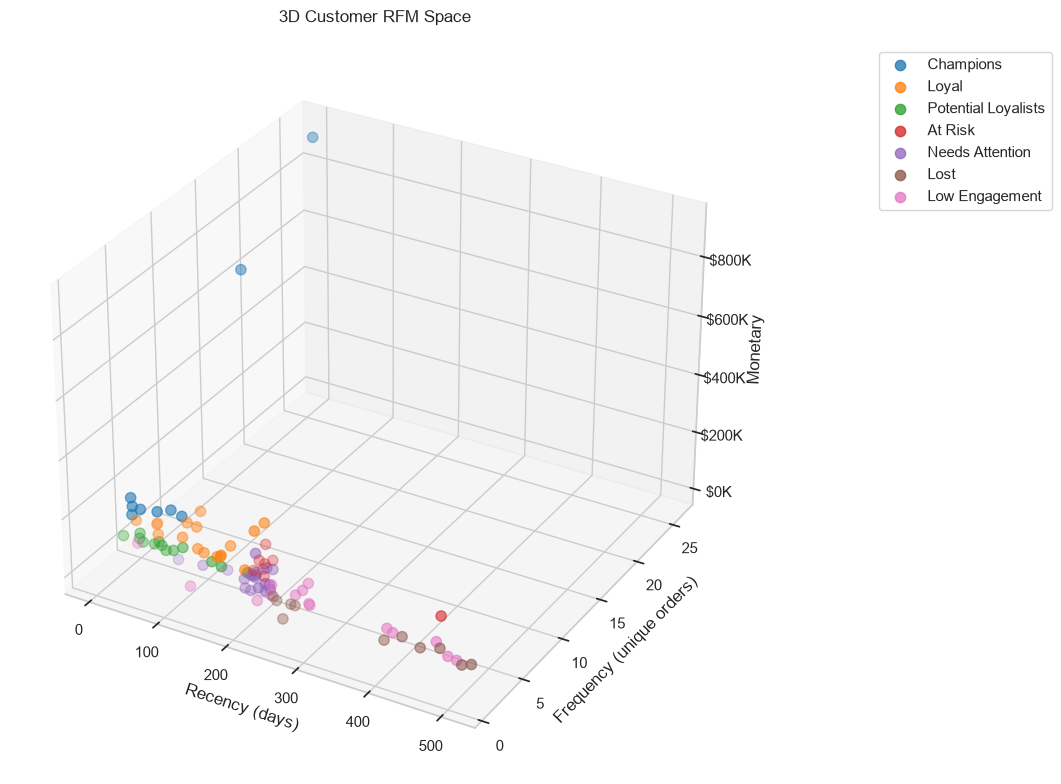

In [13]:
segments_present = [s for s in segment_order if s in rfm["Segment"].astype(str).unique()]
palette = sns.color_palette("tab10", n_colors=len(segments_present))
color_map = dict(zip(segments_present, palette))

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

for segment in segments_present:
    subset = rfm[rfm["Segment"].astype(str) == segment]
    ax.scatter(
        subset["Recency"], subset["Frequency"], subset["Monetary"],
        s=55, alpha=0.78, label=segment, color=color_map[segment]
    )

ax.set_title("3D Customer RFM Space", pad=16)
ax.set_xlabel("Recency (days)")
ax.set_ylabel("Frequency (unique orders)")
ax.set_zlabel("Monetary")
ax.zaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
ax.legend(bbox_to_anchor=(1.18, 1), loc="upper left")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_rfm_3d_scatter.png", dpi=180, bbox_inches="tight")
plt.show()

## Revenue contribution by segment

Customer count alone can be misleading. This chart compares the revenue concentration of each segment and helps prioritize campaign effort toward segments with greater economic weight.

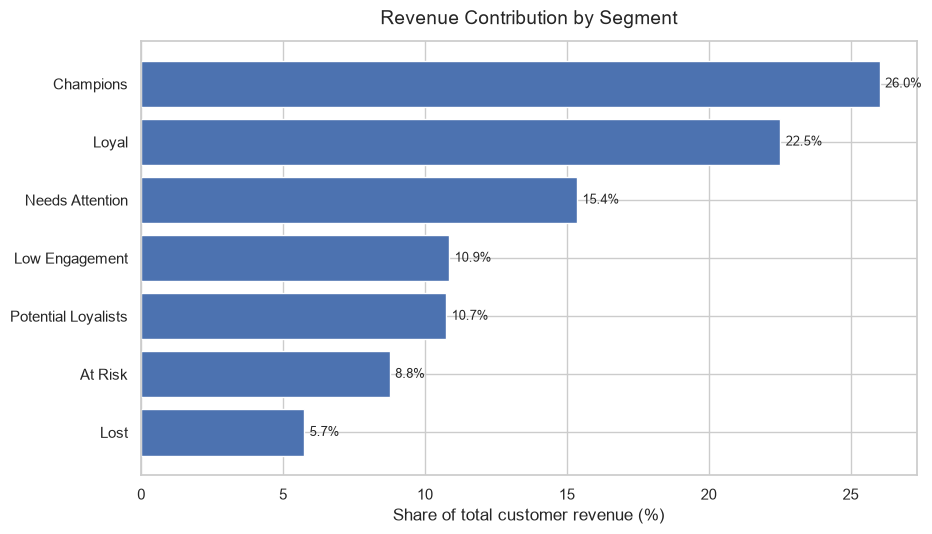

In [14]:
revenue_view = segment_summary.sort_values("Revenue_Share_Pct", ascending=True)

plt.figure(figsize=(9.5, 5.5))
ax = plt.gca()
ax.barh(revenue_view["Segment"].astype(str), revenue_view["Revenue_Share_Pct"])
ax.set_title("Revenue Contribution by Segment", fontsize=14, pad=12)
ax.set_xlabel("Share of total customer revenue (%)")
ax.set_ylabel("")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=4, fontsize=9)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_segment_revenue_share.png", dpi=180, bbox_inches="tight")
plt.show()

## Marketing-ready reports

The customer-level export contains the original RFM metrics, quartile scores, compact RFM code and final segment label. A second CSV stores the segment summary, which is convenient for campaign planning or a dashboard layer.

In [15]:
customer_export = rfm.sort_values(["Segment", "Monetary"], ascending=[True, False]).copy()

customer_export.to_csv(OUTPUT_DIR / "rfm_customer_report.csv", index=False)
segment_summary.to_csv(OUTPUT_DIR / "rfm_segment_summary.csv", index=False)
marketing_actions.to_csv(OUTPUT_DIR / "rfm_marketing_actions.csv", index=False)

print("Saved:")
print(" -", OUTPUT_DIR / "rfm_customer_report.csv")
print(" -", OUTPUT_DIR / "rfm_segment_summary.csv")
print(" -", OUTPUT_DIR / "rfm_marketing_actions.csv")

Saved:
 - outputs\rfm_customer_report.csv
 - outputs\rfm_segment_summary.csv
 - outputs\rfm_marketing_actions.csv


## Key findings

The final interpretation is generated directly from the calculated results rather than copied from preset benchmark numbers.

In [16]:
champions = rfm[rfm["Segment"] == "Champions"]
at_risk = rfm[rfm["Segment"] == "At Risk"]
lost = rfm[rfm["Segment"] == "Lost"]
champion_share = champions["Monetary"].sum() / rfm["Monetary"].sum() * 100

print(f"Champions: {len(champions)} customers, contributing {champion_share:.1f}% of total customer revenue.")
print(f"At Risk: {len(at_risk)} customers with strong historical frequency/value but weaker recency.")
print(f"Lost: {len(lost)} customers with exact RFM code 111.")
print(f"Median customer Monetary value: ${rfm['Monetary'].median():,.2f}.")
print(f"Total Monetary value represented: ${rfm['Monetary'].sum():,.2f}.")

Champions: 9 customers, contributing 26.0% of total customer revenue.
At Risk: 7 customers with strong historical frequency/value but weaker recency.
Lost: 11 customers with exact RFM code 111.
Median customer Monetary value: $86,522.61.
Total Monetary value represented: $10,032,628.85.


### Final business reading

- **Champions are few but economically important.** Retention and advocacy programs should focus on protecting this group rather than discounting it heavily.
- **At Risk customers deserve targeted win-back spend.** They have already demonstrated meaningful frequency and value, so reactivation has a stronger business rationale than broad outreach to inactive low-value buyers.
- **Potential Loyalists are the clearest growth pool.** Their stronger recency creates an opportunity to build repeat behavior before engagement fades.
- **Lost customers should be handled with cost control.** One reactivation test is reasonable, but persistent spending on unresponsive low-value customers is unlikely to be efficient.
